# 🎓 LABORATORIO N° 09 — Gradient Boosting y XGBoost
### Predicción de Churn con Telco Customer Churn

| Campo | Detalle |
|-------|--------|
| **Curso** | Minería de Datos |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Semana** | 9 |
| **Periodo** | 2026-I |
| **Alumno** | *(Escribe tu nombre aquí)* |
| **Dataset** | Telco Customer Churn — IBM |

---

## 🎯 Objetivo
Comprender, implementar y optimizar los algoritmos **Gradient Boosting** y **XGBoost** para predecir el abandono de clientes (churn) en una empresa de telecomunicaciones. Al finalizar, el estudiante será capaz de:
- Explicar el funcionamiento del boosting secuencial
- Entrenar y evaluar modelos Gradient Boosting y XGBoost
- Realizar tuning de hiperparámetros con GridSearchCV
- Interpretar la importancia de variables y su impacto empresarial
- Seleccionar el umbral de decisión óptimo según el contexto de negocio

---
## 📦 PASO 1 — Importación de librerías

**¿Qué haremos?** Cargaremos todas las librerías necesarias para el laboratorio.

**¿Por qué?** Una correcta importación garantiza reproducibilidad. Fijamos `random_state=42` para resultados consistentes.

In [ ]:
# ============================================================
# LABORATORIO 09 — Gradient Boosting y XGBoost
# Curso: Minería de Datos | Docente: Pilar Rocío Sayán Mejía
# Dataset: Telco Customer Churn (IBM)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos de ensamble
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

# Preprocesamiento y evaluación
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_STATE = 42

print("✅ Librerías importadas correctamente.")
import xgboost
print(f"📦 Versión XGBoost: {xgboost.__version__}")
print(f"📦 Versión pandas:  {pd.__version__}")
print(f"📦 Versión numpy:   {np.__version__}")

✅ Librerías importadas correctamente.
📦 Versión XGBoost: 3.2.0
📦 Versión pandas:  2.2.2
📦 Versión numpy:   2.0.2


---
## 📂 PASO 2 — Carga del dataset

**¿Qué haremos?** Cargaremos el dataset **Telco Customer Churn** desde el repositorio de IBM.

**Contexto empresarial:** Una empresa de telecomunicaciones desea predecir qué clientes abandonarán el servicio para implementar estrategias de retención proactiva.

| Variable objetivo | Valores | Significado |
|---|---|---|
| **Churn** | Yes / No | Si el cliente abandonó el servicio |

In [ ]:
# Cargar dataset Telco Customer Churn
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(URL)

print(f"✅ Dataset cargado exitosamente.")
print(f"📊 Dimensiones: {df.shape[0]:,} clientes × {df.shape[1]} variables")
print(f"\n🎯 Variable objetivo (Churn):")
print(df['Churn'].value_counts())
print(f"\n📈 Tasa de churn: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
df.head()

✅ Dataset cargado exitosamente.
📊 Dimensiones: 7,043 clientes × 21 variables

🎯 Variable objetivo (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

📈 Tasa de churn: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### ❓ Pregunta 1
¿Cuántos clientes tiene el dataset? ¿Está balanceado el target? ¿Qué implicación tiene el desbalance para el modelo de ML?

**Tu respuesta:**

---

---
## 🔍 PASO 3 — Exploración del dataset

**¿Qué haremos?** Analizaremos la estructura, tipos de variables y distribución del churn por variables clave.

**CRISP-DM:** Esta etapa corresponde a la fase de **Comprensión de Datos**.

In [ ]:
# Exploración general
print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"\nTipos de variables:")
print(df.dtypes.value_counts())
print(f"\nEstadísticas variables numéricas:")
print(df.select_dtypes(include='number').describe().round(2))

INFORMACIÓN DEL DATASET
Filas: 7,043 | Columnas: 21

Tipos de variables:
object     18
int64       2
float64     1
Name: count, dtype: int64

Estadísticas variables numéricas:
       SeniorCitizen   tenure  MonthlyCharges
count        7043.00  7043.00         7043.00
mean            0.16    32.37           64.76
std             0.37    24.56           30.09
min             0.00     0.00           18.25
25%             0.00     9.00           35.50
50%             0.00    29.00           70.35
75%             0.00    55.00           89.85
max             1.00    72.00          118.75


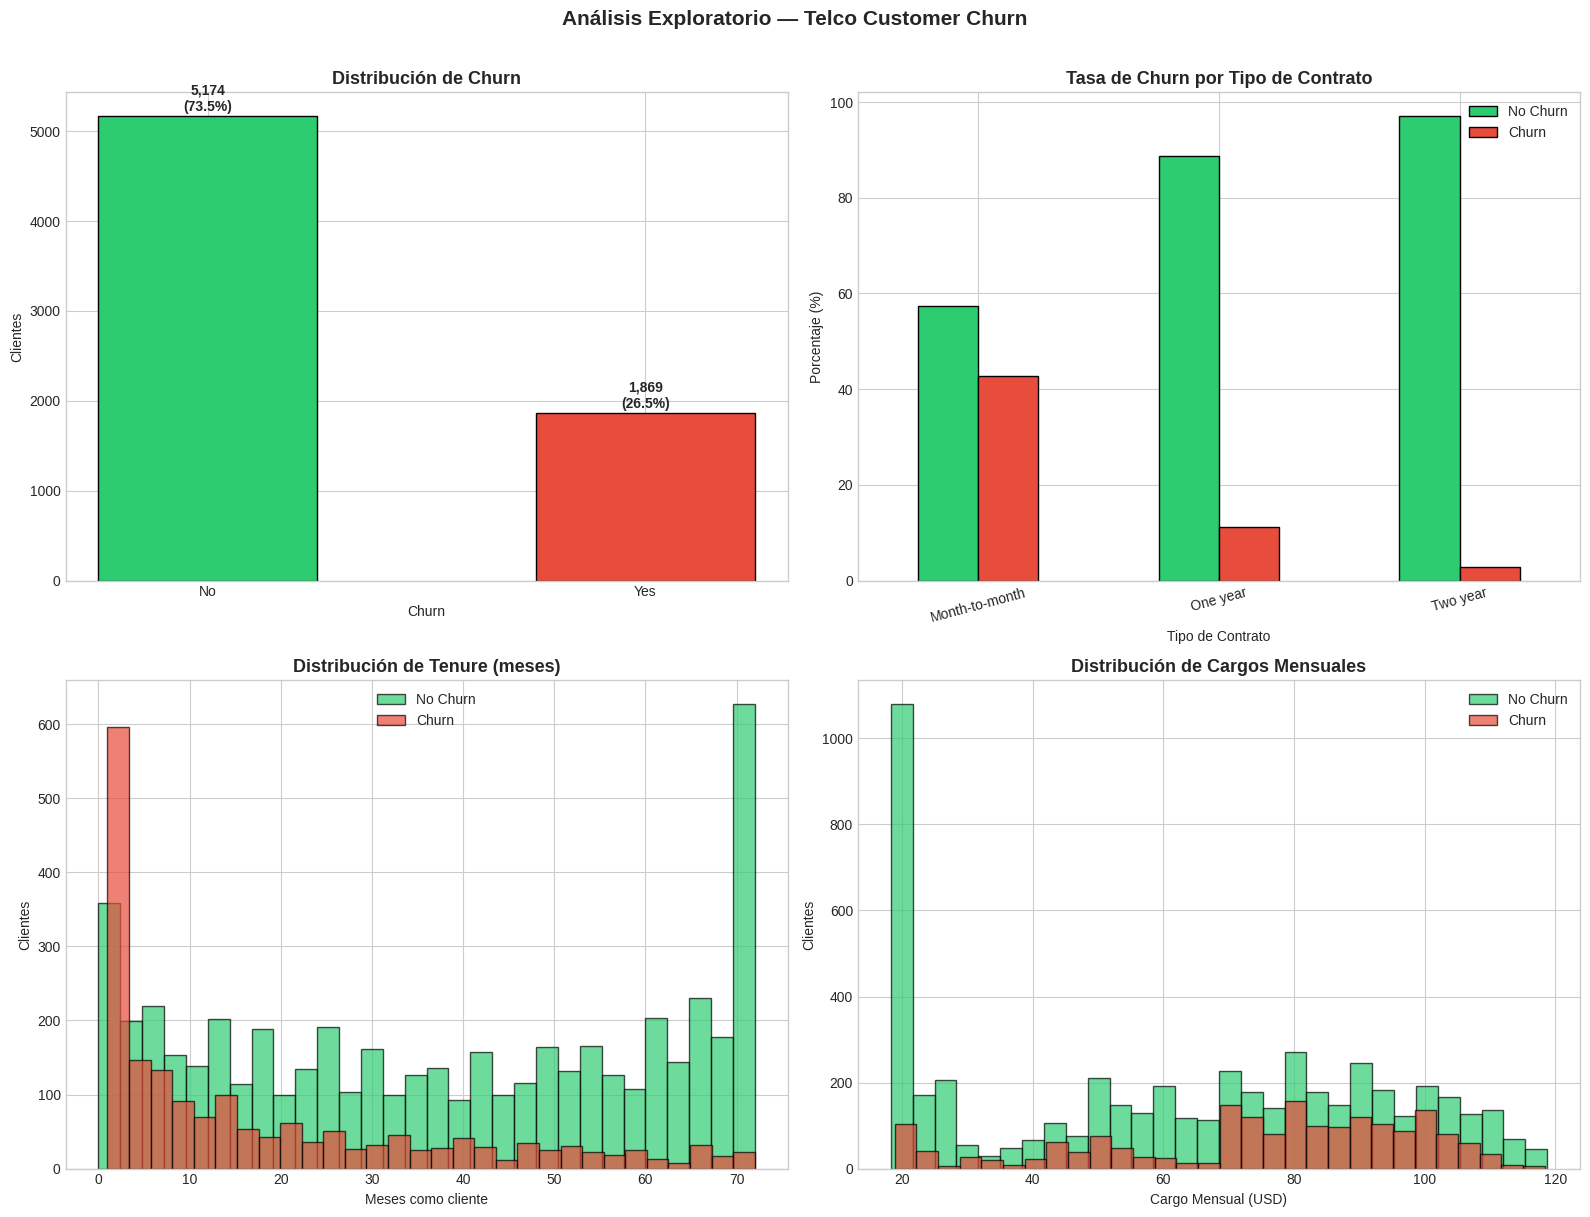

✅ Gráficos de exploración generados.


In [ ]:
# Visualización: Distribución de Churn por variables clave
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución general de Churn
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0,0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0,0].set_title('Distribución de Churn', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Churn')
axes[0,0].set_ylabel('Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0,0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# 2. Churn por tipo de contrato
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=axes[0,1], color=colors, edgecolor='black')
axes[0,1].set_title('Tasa de Churn por Tipo de Contrato', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Tipo de Contrato')
axes[0,1].set_ylabel('Porcentaje (%)')
axes[0,1].legend(['No Churn', 'Churn'])
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Churn por tenure (meses)
df_churn = df[df['Churn'] == 'Yes']['tenure']
df_no_churn = df[df['Churn'] == 'No']['tenure']
axes[1,0].hist(df_no_churn, bins=30, alpha=0.7, color='#2ecc71', label='No Churn', edgecolor='black')
axes[1,0].hist(df_churn, bins=30, alpha=0.7, color='#e74c3c', label='Churn', edgecolor='black')
axes[1,0].set_title('Distribución de Tenure (meses)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Meses como cliente')
axes[1,0].set_ylabel('Clientes')
axes[1,0].legend()

# 4. Cargos mensuales
df_churn_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
df_no_churn_charges = df[df['Churn'] == 'No']['MonthlyCharges']
axes[1,1].hist(df_no_churn_charges, bins=30, alpha=0.7, color='#2ecc71', label='No Churn', edgecolor='black')
axes[1,1].hist(df_churn_charges, bins=30, alpha=0.7, color='#e74c3c', label='Churn', edgecolor='black')
axes[1,1].set_title('Distribución de Cargos Mensuales', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Cargo Mensual (USD)')
axes[1,1].set_ylabel('Clientes')
axes[1,1].legend()

plt.suptitle('Análisis Exploratorio — Telco Customer Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráficos de exploración generados.")

### ❓ Pregunta 2
¿Qué tipo de contrato tiene mayor tasa de churn? ¿Los clientes con mayor tenure (antigüedad) tienden a quedarse o irse? ¿Por qué?

**Tu respuesta:**

---

---
## 🧹 PASO 4 — Limpieza de datos

**¿Qué haremos?** Corregiremos la variable `TotalCharges` (viene como string), eliminaremos el ID de cliente (no predictivo) y trataremos los valores faltantes.

**¿Por qué?** Los modelos de ML no pueden procesar datos con errores o tipos incorrectos.

In [ ]:
# Limpieza de datos

# 1. Eliminar customerID (no aporta información predictiva)
df = df.drop('customerID', axis=1)
print("✅ customerID eliminado.")

# 2. Convertir TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Valores nulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")

# 3. Imputar valores faltantes con la mediana
mediana_tc = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_tc)
print(f"Imputados con mediana: ${mediana_tc:.2f}")

# 4. Verificación final
print(f"\n✅ Limpieza completada.")
print(f"Dimensiones finales: {df.shape}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

# Estadísticas de variables numéricas
print("\nEstadísticas finales variables numéricas:")
print(df.select_dtypes(include='number').describe().round(2))

✅ customerID eliminado.
Valores nulos en TotalCharges: 11
Imputados con mediana: $1397.47

✅ Limpieza completada.
Dimensiones finales: (7043, 20)
Valores nulos restantes: 0

Estadísticas finales variables numéricas:
       SeniorCitizen   tenure  MonthlyCharges  TotalCharges
count        7043.00  7043.00         7043.00       7043.00
mean            0.16    32.37           64.76       2281.92
std             0.37    24.56           30.09       2265.27
min             0.00     0.00           18.25         18.80
25%             0.00     9.00           35.50        402.22
50%             0.00    29.00           70.35       1397.48
75%             0.00    55.00           89.85       3786.60
max             1.00    72.00          118.75       8684.80


---
## 🔄 PASO 5 — Transformación de variables categóricas

**¿Qué haremos?** Convertiremos todas las variables categóricas (texto) a numéricas mediante **Label Encoding**.

**¿Por qué?** XGBoost y Gradient Boosting requieren entrada numérica. Label Encoding es eficiente para variables binarias y ordinales.

In [ ]:
# Transformación de variables categóricas con Label Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Variables categóricas a transformar ({len(cat_cols)}):")
print(cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"\n✅ Transformación completada.")
print(f"Churn codificado: 0 = No Churn | 1 = Churn")
print(f"\nDistribución Churn (codificada):")
print(df['Churn'].value_counts())
print("\nPrimeras filas del dataset transformado:")
df.head()

Variables categóricas a transformar (16):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

✅ Transformación completada.
Churn codificado: 0 = No Churn | 1 = Churn

Distribución Churn (codificada):
Churn
0    5174
1    1869
Name: count, dtype: int64

Primeras filas del dataset transformado:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


### ❓ Pregunta 3
¿Por qué no usamos One-Hot Encoding en este caso? ¿Cuándo Label Encoding puede introducir un sesgo no deseado en el modelo?

**Tu respuesta:**

---

---
## ✂️ PASO 6 — División Train / Test

**¿Qué haremos?** Dividiremos el dataset en entrenamiento (80%) y prueba (20%) con estratificación para mantener la proporción de churn en ambos conjuntos.

In [ ]:
# Separar features y target
X = df.drop('Churn', axis=1)
y = df['Churn']

# División estratificada Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Calcular ratio para desbalance (usado en XGBoost)
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f"✅ División completada.")
print(f"\n📊 Tamaño de conjuntos:")
print(f"  Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:  {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Features: {X_train.shape[1]} variables")
print(f"\n🎯 Proporción de Churn (stratify garantiza esto):")
print(f"  Train — Churn: {y_train.mean()*100:.1f}%")
print(f"  Test  — Churn: {y_test.mean()*100:.1f}%")
print(f"\n⚖️  Ratio Neg/Pos (scale_pos_weight): {neg_pos_ratio:.2f}")

✅ División completada.

📊 Tamaño de conjuntos:
  Train: 5,634 muestras (80%)
  Test:  1,409 muestras (20%)
  Features: 19 variables

🎯 Proporción de Churn (stratify garantiza esto):
  Train — Churn: 26.5%
  Test  — Churn: 26.5%

⚖️  Ratio Neg/Pos (scale_pos_weight): 2.77


---
## 🌲 PASO 7 — Modelo Gradient Boosting

**¿Qué haremos?** Entrenaremos el modelo **GradientBoostingClassifier** de scikit-learn. Este modelo construye árboles secuencialmente, donde cada árbol corrige los errores del anterior minimizando el gradiente de la función de pérdida.

**Hiperparámetros clave:**
- `n_estimators=100`: número de árboles
- `learning_rate=0.1`: cuánto aporta cada árbol
- `max_depth=3`: profundidad máxima por árbol

🔄 Entrenando Gradient Boosting...

📈 MÉTRICAS — GRADIENT BOOSTING
  Accuracy:  0.8013
  Precision: 0.6655
  Recall:    0.5053
  F1-Score:  0.5745
  AUC-ROC:   0.8449

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



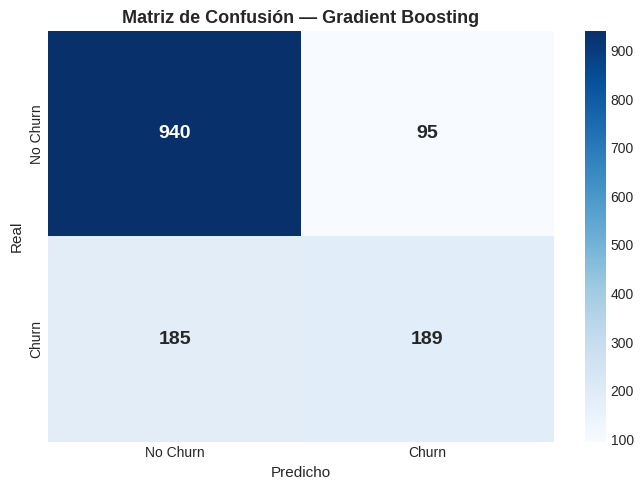


🔍 FP (Falsos Positivos): 95 | FN (Falsos Negativos): 185


In [ ]:
# Entrenamiento del modelo Gradient Boosting
print("🔄 Entrenando Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb_model.fit(X_train, y_train)

# Predicciones
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Métricas
print("\n📈 MÉTRICAS — GRADIENT BOOSTING")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_gb):.4f}")
print("=" * 45)

print("\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred_gb, target_names=['No Churn', 'Churn']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Matriz de Confusión — Gradient Boosting', fontsize=13, fontweight='bold')
ax.set_ylabel('Real', fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
plt.tight_layout()
plt.savefig('cm_gradient_boosting.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🔍 FP (Falsos Positivos): {cm[0][1]} | FN (Falsos Negativos): {cm[1][0]}")

### ❓ Pregunta 4
En el contexto de churn: ¿Qué representa un Falso Positivo (FP)? ¿Y un Falso Negativo (FN)? ¿Cuál tiene mayor costo económico para TelcoPerú y por qué?

**Tu respuesta:**

---

---
## ⚡ PASO 8 — Modelo XGBoost

**¿Qué haremos?** Entrenaremos **XGBoost** (Extreme Gradient Boosting), desarrollado por Tianqi Chen. Añadimos `scale_pos_weight` para compensar el desbalance de clases.

**Ventajas de XGBoost sobre GB clásico:**
- Regularización L1/L2 integrada
- Poda de árboles (prune) basada en ganancia
- Soporte nativo para datos faltantes
- Procesamiento paralelo → mucho más rápido
- `scale_pos_weight` para clases desbalanceadas

🔄 Entrenando XGBoost...

📈 MÉTRICAS — XGBOOST
  Accuracy:  0.7516
  Precision: 0.5213
  Recall:    0.7861
  F1-Score:  0.6269
  AUC-ROC:   0.8444

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



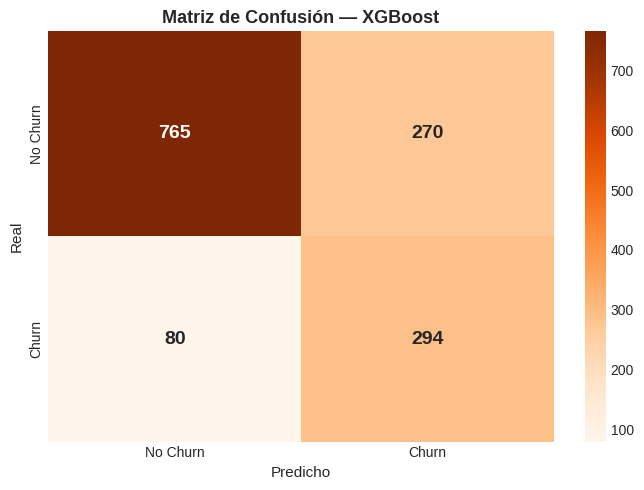

In [ ]:
# Entrenamiento del modelo XGBoost
print("🔄 Entrenando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=neg_pos_ratio,   # Manejo de desbalance de clases
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Métricas
print("\n📈 MÉTRICAS — XGBOOST")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("=" * 45)

print("\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

# Matriz de confusión XGBoost
fig, ax = plt.subplots(figsize=(7, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Matriz de Confusión — XGBoost', fontsize=13, fontweight='bold')
ax.set_ylabel('Real', fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
plt.tight_layout()
plt.savefig('cm_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

### ❓ Pregunta 5
¿Qué es `scale_pos_weight`? ¿Cómo afecta al Recall del modelo cuando las clases están desbalanceadas? ¿Por qué es importante en este dataset?

**Tu respuesta:**

---

---
## 📊 PASO 9 — Comparación de modelos

**¿Qué haremos?** Compararemos **Gradient Boosting**, **XGBoost** y **Random Forest** en todas las métricas, y generaremos las curvas ROC comparativas.

In [ ]:
# Entrenar Random Forest para comparación
print("🔄 Entrenando Random Forest para comparación...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("✅ Random Forest entrenado.")

# Tabla comparativa de métricas
models_results = {
    'Gradient Boosting': (y_pred_gb, y_prob_gb),
    'XGBoost':           (y_pred_xgb, y_prob_xgb),
    'Random Forest':     (y_pred_rf, y_prob_rf)
}

print("\n" + "=" * 75)
print("📊 COMPARACIÓN DE MODELOS — Telco Customer Churn")
print("=" * 75)
print(f"{'Modelo':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>10}")
print("-" * 75)
for name, (pred, prob) in models_results.items():
    print(f"{name:<22} "
          f"{accuracy_score(y_test, pred):>10.4f} "
          f"{precision_score(y_test, pred):>10.4f} "
          f"{recall_score(y_test, pred):>8.4f} "
          f"{f1_score(y_test, pred):>8.4f} "
          f"{roc_auc_score(y_test, prob):>10.4f}")
print("=" * 75)

🔄 Entrenando Random Forest para comparación...
✅ Random Forest entrenado.

📊 COMPARACIÓN DE MODELOS — Telco Customer Churn
Modelo                   Accuracy  Precision   Recall       F1    AUC-ROC
---------------------------------------------------------------------------
Gradient Boosting          0.8013     0.6655   0.5053   0.5745     0.8449
XGBoost                    0.7516     0.5213   0.7861   0.6269     0.8444
Random Forest              0.7921     0.6373   0.5027   0.5620     0.8225


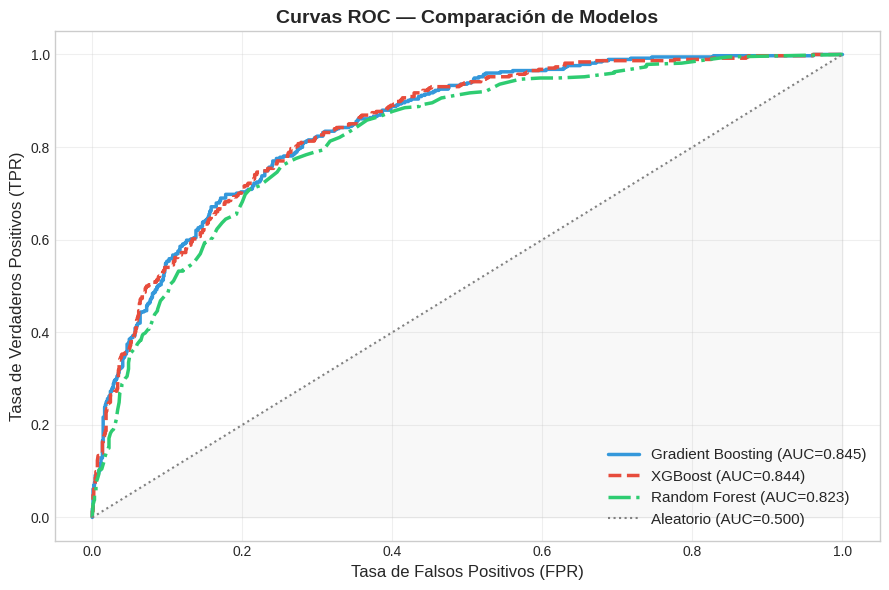

In [ ]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(9, 6))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71']
linestyles = ['-', '--', '-.']

for (name, (_, prob)), color, ls in zip(models_results.items(), colors_roc, linestyles):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2.5, color=color, linestyle=ls, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1.5, label='Aleatorio (AUC=0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_roc_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### ❓ Pregunta 6
¿Qué modelo obtiene el mayor AUC-ROC? ¿Por qué el AUC es más informativa que el Accuracy en datasets desbalanceados?

**Tu respuesta:**

### ❓ Pregunta 7
Una curva ROC con AUC = 0.5 representa un modelo aleatorio. ¿Qué significa un AUC de 0.85? ¿Y uno de 0.60? ¿Cuándo considerarías un modelo como "aceptable" para producción?

**Tu respuesta:**

---

---
## 🔧 PASO 10 — Tuning de hiperparámetros con GridSearchCV

**¿Qué haremos?** Buscaremos la combinación óptima de hiperparámetros de XGBoost usando **validación cruzada de 5 folds**. El scoring es AUC-ROC.

**¿Por qué?** Los hiperparámetros por defecto raramente son los mejores. GridSearchCV evalúa sistemáticamente todas las combinaciones posibles.

> ⏱️ **Nota:** Este paso puede tardar 2-4 minutos en Google Colab.

In [ ]:
# GridSearchCV para XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'scale_pos_weight': [neg_pos_ratio]
}

# Total de combinaciones = 2 × 3 × 3 × 1 × 5 folds = 90 modelos
n_combinations = 2 * 3 * 3
print(f"🔍 Iniciando búsqueda de hiperparámetros...")
print(f"   Combinaciones a evaluar: {n_combinations} × 5 folds CV = {n_combinations*5} modelos")

grid_search = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

# Mejor modelo
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print(f"\n✅ MEJORES HIPERPARÁMETROS:")
for k, v in grid_search.best_params_.items():
    print(f"   {k}: {v}")
print(f"   AUC-ROC en CV: {grid_search.best_score_:.4f}")

print(f"\n📈 MÉTRICAS — XGBoost OPTIMIZADO vs BASE")
print("=" * 55)
print(f"{'Métrica':<15} {'XGBoost Base':>15} {'XGBoost Optimizado':>20}")
print("-" * 55)
for metric, base_val, opt_val in [
    ('Accuracy',  accuracy_score(y_test, y_pred_xgb),  accuracy_score(y_test, y_pred_best)),
    ('Precision', precision_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_best)),
    ('Recall',    recall_score(y_test, y_pred_xgb),    recall_score(y_test, y_pred_best)),
    ('F1-Score',  f1_score(y_test, y_pred_xgb),        f1_score(y_test, y_pred_best)),
    ('AUC-ROC',   roc_auc_score(y_test, y_prob_xgb),   roc_auc_score(y_test, y_prob_best))
]:
    diff = opt_val - base_val
    arrow = '⬆' if diff > 0 else ('⬇' if diff < 0 else '=')
    print(f"{metric:<15} {base_val:>15.4f} {opt_val:>20.4f}  {arrow} {diff:+.4f}")
print("=" * 55)

🔍 Iniciando búsqueda de hiperparámetros...
   Combinaciones a evaluar: 18 × 5 folds CV = 90 modelos
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ MEJORES HIPERPARÁMETROS:
   learning_rate: 0.05
   max_depth: 3
   n_estimators: 100
   scale_pos_weight: 2.768561872909699
   AUC-ROC en CV: 0.8461

📈 MÉTRICAS — XGBoost OPTIMIZADO vs BASE
Métrica            XGBoost Base   XGBoost Optimizado
-------------------------------------------------------
Accuracy                 0.7516               0.7410  ⬇ -0.0106
Precision                0.5213               0.5077  ⬇ -0.0136
Recall                   0.7861               0.7968  ⬆ +0.0107
F1-Score                 0.6269               0.6202  ⬇ -0.0067
AUC-ROC                  0.8444               0.8447  ⬆ +0.0002


### ❓ Pregunta 8
¿Cuántos modelos evaluó el GridSearchCV en total? ¿Mejoró el AUC respecto al modelo base? ¿Qué combinación de hiperparámetros resultó óptima? ¿Tiene sentido intuitivo?

**Tu respuesta:**

---

---
## 🏆 PASO 11 — Importancia de variables (Feature Importance)

**¿Qué haremos?** Visualizaremos las **15 variables más importantes** según el modelo XGBoost optimizado. La importancia se mide por el **Gain** (ganancia promedio en la función de pérdida al usar esa variable para hacer splits).

**¿Por qué?** Identificar las variables clave permite tomar decisiones empresariales informadas y simplificar el modelo en producción.

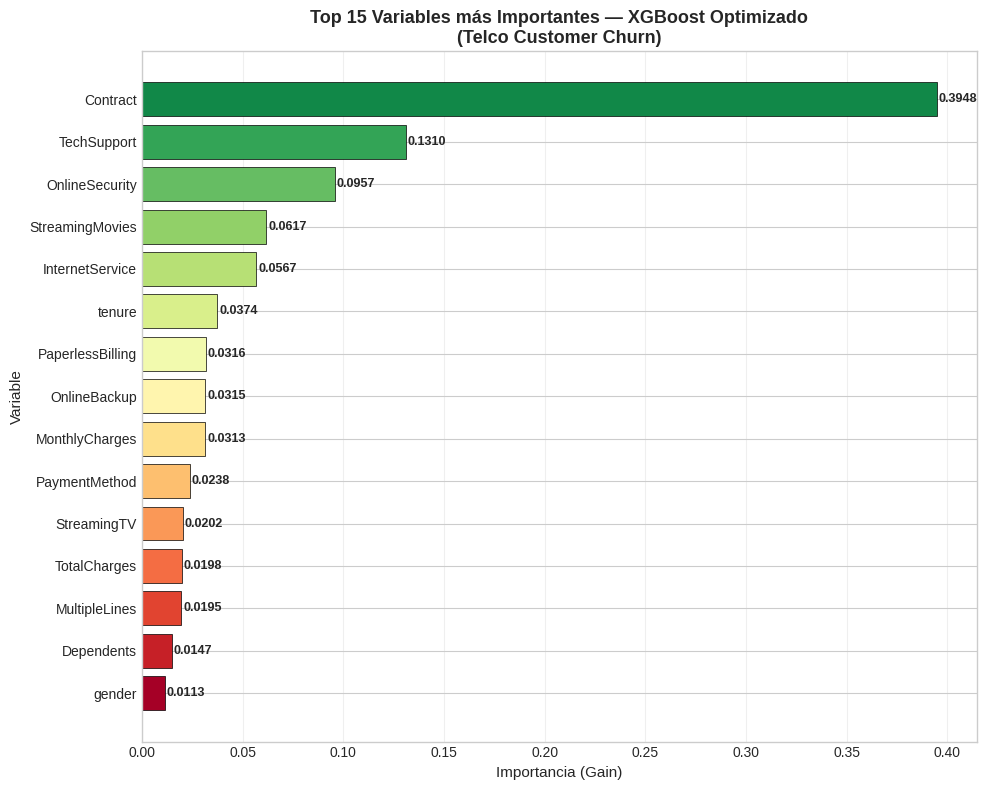


🏆 TOP 5 VARIABLES MÁS IMPORTANTES:
  1. Contract             → 0.3948
  2. TechSupport          → 0.1310
  3. OnlineSecurity       → 0.0957
  4. StreamingMovies      → 0.0617
  5. InternetService      → 0.0567


In [ ]:
# Feature Importance del mejor modelo XGBoost
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

# Gráfico de importancia de variables
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.RdYlGn
colors_fi = [cmap(i / len(feature_importance)) for i in range(len(feature_importance))]
bars = ax.barh(feature_importance['feature'], feature_importance['importance'],
               color=colors_fi, edgecolor='black', linewidth=0.5)

# Agregar valores en las barras
for bar, val in zip(bars, feature_importance['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Variables más Importantes — XGBoost Optimizado\n(Telco Customer Churn)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gain)', fontsize=11)
ax.set_ylabel('Variable', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 variables
print("\n🏆 TOP 5 VARIABLES MÁS IMPORTANTES:")
print("=" * 40)
top5 = feature_importance.tail(5).iloc[::-1]
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['feature']:<20} → {row['importance']:.4f}")
print("=" * 40)

### ❓ Pregunta 9
¿Cuál es la variable más importante para predecir el churn? ¿Tiene sentido desde el punto de vista del negocio? ¿Qué acción comercial concreta recomendarías basándote en las 3 variables más importantes?

**Tu respuesta:**

---

---
## 🎯 PASO 12 — Análisis del umbral de decisión

**¿Qué haremos?** Analizaremos cómo cambia el comportamiento del modelo al variar el **umbral de decisión** (por defecto 0.5). Esto es crucial para adaptar el modelo al costo de negocio.

**Concepto clave:**
- Umbral bajo (ej: 0.3) → más predicciones de churn → mayor Recall, menor Precision
- Umbral alto (ej: 0.7) → menos predicciones de churn → menor Recall, mayor Precision

**En negocio:** Si capturar clientes en riesgo es más importante que la precisión de las campañas → bajar el umbral.

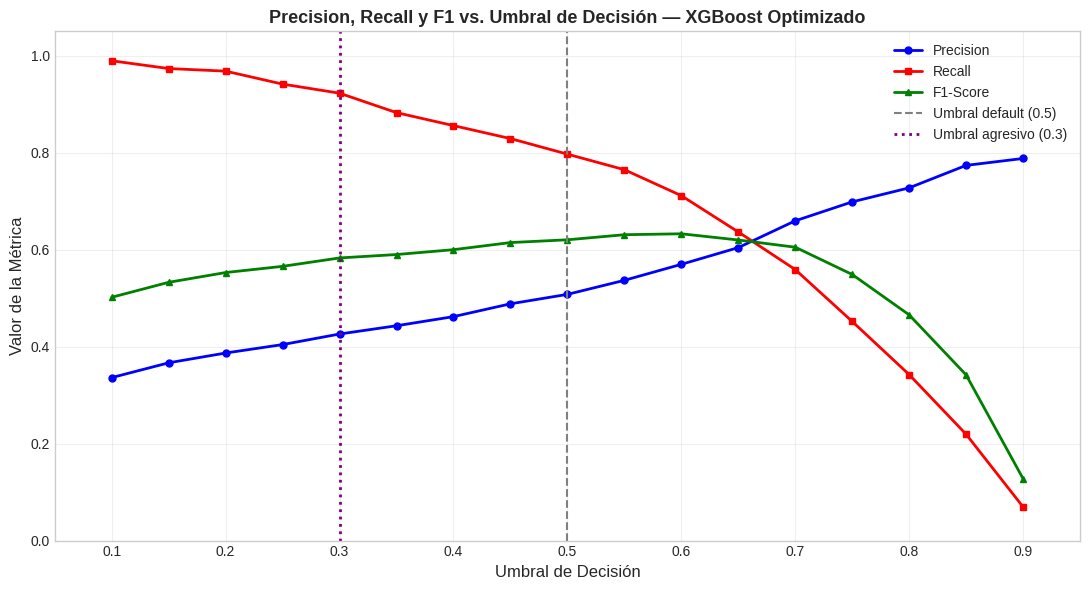


📊 COMPARACIÓN DE UMBRALES:
Umbral                     Precision   Recall   F1-Score
-----------------------------------------------------------------
Umbral 0.5 (default)          0.5077   0.7968     0.6202
Umbral 0.3 (agresivo)         0.4259   0.9225     0.5828
Umbral 0.4                    0.4618   0.8556     0.5998


In [ ]:
# Análisis de umbral de decisión
thresholds = np.arange(0.1, 0.91, 0.05)
precision_list, recall_list, f1_list = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    precision_list.append(precision_score(y_test, y_pred_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_t))
    f1_list.append(f1_score(y_test, y_pred_t, zero_division=0))

# Gráfico Precision-Recall-F1 vs Umbral
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(thresholds, precision_list, 'b-o', lw=2, markersize=5, label='Precision')
ax.plot(thresholds, recall_list, 'r-s', lw=2, markersize=5, label='Recall')
ax.plot(thresholds, f1_list, 'g-^', lw=2, markersize=5, label='F1-Score')
ax.axvline(x=0.5, color='gray', linestyle='--', lw=1.5, label='Umbral default (0.5)')
ax.axvline(x=0.3, color='purple', linestyle=':', lw=2, label='Umbral agresivo (0.3)')
ax.set_title('Precision, Recall y F1 vs. Umbral de Decisión — XGBoost Optimizado',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Umbral de Decisión', fontsize=12)
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('umbral_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparar umbrales específicos
print("\n📊 COMPARACIÓN DE UMBRALES:")
print("=" * 65)
print(f"{'Umbral':<25} {'Precision':>10} {'Recall':>8} {'F1-Score':>10}")
print("-" * 65)
for t, name in [(0.5, 'Umbral 0.5 (default)'), (0.3, 'Umbral 0.3 (agresivo)'), (0.4, 'Umbral 0.4')]:
    y_pred_t = (y_prob_best >= t).astype(int)
    print(f"{name:<25} {precision_score(y_test, y_pred_t):>10.4f} "
          f"{recall_score(y_test, y_pred_t):>8.4f} "
          f"{f1_score(y_test, y_pred_t):>10.4f}")
print("=" * 65)

### ❓ Pregunta 10
Al bajar el umbral de 0.5 a 0.3: ¿Qué métrica mejora y cuál empeora? En una campaña de retención donde cada oferta cuesta S/. 50 pero retener un cliente vale S/. 800, ¿qué umbral usarías y por qué?

**Tu respuesta:**

---

---
## 🏢 ACTIVIDAD 3: Caso de estudio — TelcoPerú

### Contexto empresarial

**TelcoPerú** opera en el mercado peruano con **2.5 millones de clientes** móviles. El área de Customer Experience ha detectado que la tasa de abandono es del **26%**, lo que representa una pérdida anual estimada de **S/. 45 millones**.

El equipo de Data Science ha desarrollado el modelo XGBoost de este laboratorio y debe presentar los resultados al directorio para implementar una estrategia de retención proactiva.

> **Instrucciones:** Responde cada pregunta en esta celda de Markdown con análisis detallado y fundamentado. Considera métricas, costo-beneficio e impacto estratégico.

In [ ]:
# Resumen ejecutivo de todos los modelos para el caso
print("=" * 70)
print("📊 RESUMEN EJECUTIVO — Modelos para TelcoPerú")
print("=" * 70)

todos_modelos = {
    'Gradient Boosting': (y_pred_gb, y_prob_gb),
    'XGBoost Base':      (y_pred_xgb, y_prob_xgb),
    'XGBoost Optimizado': (y_pred_best, y_prob_best),
    'Random Forest':     (y_pred_rf, y_prob_rf)
}

print(f"{'Modelo':<25} {'AUC-ROC':>10} {'F1-Score':>10} {'Recall':>8} {'Precision':>10}")
print("-" * 70)
for name, (pred, prob) in todos_modelos.items():
    print(f"{name:<25} "
          f"{roc_auc_score(y_test, prob):>10.4f} "
          f"{f1_score(y_test, pred):>10.4f} "
          f"{recall_score(y_test, pred):>8.4f} "
          f"{precision_score(y_test, pred):>10.4f}")
print("=" * 70)

# Proyección empresarial
print("\n💰 PROYECCIÓN EMPRESARIAL (con XGBoost Optimizado, umbral=0.5):")
cm_best = confusion_matrix(y_test, y_pred_best)
TP = cm_best[1][1]  # Clientes en riesgo correctamente identificados
FP = cm_best[0][1]  # No-churn mal clasificados
FN = cm_best[1][0]  # Churn no detectado

# Escalar a 2.5M clientes
escala = 2_500_000 / len(y_test)
print(f"  Clientes en riesgo detectados (TP escalado): {TP * escala:,.0f}")
print(f"  Falsos alarmas (FP escalado):                {FP * escala:,.0f}")
print(f"  Churn no detectado (FN escalado):           {FN * escala:,.0f}")
costo_fp = FP * escala * 50          # S/. 50 por oferta innecesaria
valor_tp = TP * escala * 800         # S/. 800 por cliente retenido
print(f"\n  Costo total de FP (S/. 50/oferta):  S/. {costo_fp:>12,.0f}")
print(f"  Valor total de TP (S/. 800/retención): S/. {valor_tp:>12,.0f}")
print(f"  ROI neto estimado:                   S/. {(valor_tp - costo_fp):>12,.0f}")

📊 RESUMEN EJECUTIVO — Modelos para TelcoPerú
Modelo                       AUC-ROC   F1-Score   Recall  Precision
----------------------------------------------------------------------
Gradient Boosting             0.8449     0.5745   0.5053     0.6655
XGBoost Base                  0.8444     0.6269   0.7861     0.5213
XGBoost Optimizado            0.8447     0.6202   0.7968     0.5077
Random Forest                 0.8225     0.5620   0.5027     0.6373

💰 PROYECCIÓN EMPRESARIAL (con XGBoost Optimizado, umbral=0.5):
  Clientes en riesgo detectados (TP escalado): 528,744
  Falsos alarmas (FP escalado):                512,775
  Churn no detectado (FN escalado):           134,847

  Costo total de FP (S/. 50/oferta):  S/.   25,638,751
  Valor total de TP (S/. 800/retención): S/.  422,995,032
  ROI neto estimado:                   S/.  397,356,281


### ❓ Pregunta A
¿Qué modelo recomendarías implementar en TelcoPerú? Justifica tu respuesta considerando AUC-ROC, F1-Score, interpretabilidad y facilidad de mantenimiento en producción.

**Tu respuesta:**

---

### ❓ Pregunta B
Basándote en las 3 variables más importantes del modelo, ¿qué acciones comerciales concretas recomendarías al área de Marketing de TelcoPerú? (Ej: si 'Contract' es clave → ¿qué haría el área comercial?)

**Tu respuesta:**

---

### ❓ Pregunta C
Según la proyección empresarial calculada en el código: con umbral 0.5, ¿cuál es el ROI neto estimado? ¿Cambiarías el umbral para maximizar la ganancia? Justifica.

**Tu respuesta:**

---

### ❓ Pregunta D
XGBoost fue diseñado para datos tabulares. ¿Qué ventajas tendría sobre una Red Neuronal Profunda para este dataset de ~7,000 registros? ¿En qué escenario la red neuronal sería mejor?

**Tu respuesta:**

---

### ❓ Pregunta E
Propón 3 mejoras adicionales al pipeline para aumentar el AUC-ROC en producción (considera: feature engineering, técnicas de balanceo como SMOTE, ensambles más complejos, o variables externas).

**Tu respuesta:**

---

---
## 📝 Conclusiones

Escribe tus conclusiones técnicas y de aprendizaje del laboratorio:

**1.** *(Sobre Gradient Boosting y XGBoost)*

**2.** *(Sobre el dataset y la importancia de variables)*

**3.** *(Sobre el tuning de hiperparámetros)*

**4.** *(Sobre el impacto empresarial del modelo)*

---

## 📚 Referencias

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media. Capítulo 7.
2. Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*.
3. Lakshmanan, V. et al. (2021). *Practical Machine Learning for Computer Vision*. O'Reilly Media.
4. Documentación oficial XGBoost: https://xgboost.readthedocs.io
5. IBM Telco Customer Churn Dataset: https://github.com/IBM/telco-customer-churn-on-icp4d

---
*Laboratorio desarrollado para el curso de Minería de Datos — 2026-I*  
*Docente: Pilar Rocío Sayán Mejía*